In [ ]:
"""
2D Parameter Sweep: Amplitude vs K_c (Duffing nonlinearity)
Finite Element model with parallel execution
"""

# =========================================================
# Imports
# =========================================================
import sys
import json
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pickle

from pathlib import Path
from datetime import datetime
from collections import defaultdict
from joblib import Parallel, delayed

# =========================================================
# Project path
# =========================================================
project_root = Path.cwd().resolve().parents[2]   # notebook use
sys.path.append(str(project_root))

from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models.FE1 import PiezoBeamFE, solve_newmark

# =========================================================
# Sweep configuration
# =========================================================
K_p = 0.032
interface_idx = 10
beta = 0.3
# # ======= K_p sweep in frequency domain =======

ki0 = 4000
ki1 = ki0 / (1 - beta)**2 
ki2 = ki0 / (1 + beta)**2 


K_i = np.array([ki1, ki2] *(interface_idx//2) + [ki2, ki1] *(15-interface_idx//2) + [ki2])

R_c = 1e3

t_end = 1
f0 = 1000
f1 = 6000
dt = 1 / f1 / 50

amp_list = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]) * 125
# amp_list = np.array([0.05, 0.1, 0.15, 0.2]) * 125

kc_magnitudes = [2e10, 3e10, 4e10, 5e10, 6e10]
kc_magnitudes = [2e10, 4e10, 5e10]
Kc_cases = [
	{
		"label": f"Kc_{i}",      # or f"Kc_{kc:.2e}" if you prefer
		"kc_vec": np.array([-kc, kc] * (interface_idx//2) + [kc, -kc] * (15-interface_idx//2)   )
	}
	for i, kc in enumerate(kc_magnitudes)
]


# =========================================================
# FE parameters (frozen)
# =========================================================
# params_fe = PiezoBeamParams(
# 	hp=0.252e-3,
# 	hs=0.51e-3,
# 	d31=-1.48e-10,
# 	eps_r=1700
# )
# params_fe.zeta_p = 0.0151 * 8
# params_fe.zeta_q = 0.0392 * 10
# Setup FE model with same parameters
params_fe = PiezoBeamParams()
params_fe.zeta_p = 0.0151 * 8
params_fe.zeta_q = 0.0392 * 10

# Create FE model
fe = PiezoBeamFE(params_fe)

# =========================================================
# Timestamp & output paths
# =========================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_dat_dir = Path.cwd() / "sim_dat"



png_filename = f"FE_2D_sweep_Kp={K_p:.3f}_Ki={K_i.mean():.0f}_{timestamp}.png"
npz_filename = f"FE_2D_sweep_Kp={K_p:.3f}_Ki={K_i.mean():.0f}_{timestamp}.npz"
err_filename = f"FE_2D_sweep_errors_{timestamp}.json"

# =========================================================
# Simulation kernel (PURE FUNCTION)
# =========================================================
def run_single_simulation(
	amp, kc, kc_label,
	K_p, K_i, R_c,
	fe_params,
	dt, t_end, f0, f1
):
	try:
		fe = PiezoBeamFE(fe_params)

		def v_exc(t):
			return amp * np.sin(
				2 * np.pi * (f0 + t * (f1 - f0) / t_end) * t
			)

		ode = fe.build_ode_system(
			j_exc=30,
			K_c=kc,
			K_i=K_i,
			K_p=K_p,
			R_c=R_c,
			v_exc=v_exc
		)

		out = solve_newmark(
			ode=ode,
			dt=dt,
			t_end=t_end,
			beta=0.25,
			gamma=0.5,
			newton_tol=1e-8,
			newton_maxiter=8,
			x0=np.zeros(ode.M.shape[0]),
			x_dot0=np.zeros(ode.M.shape[0]),
			do_spectral=True
		)

		
		return dict(
			ok=True,
			amp=amp,
			kc=kc,
			kc_label=kc_label,
			result=out
		)

	except Exception as e:
		return dict(
			ok=False,
			amp=amp,
			kc=kc,
			kc_label=kc_label,
			error=str(e),
			exception=type(e).__name__
		)

# =========================================================
# Build sweep grid
# =========================================================
sweep = [
	{
		"amp": amp,
		"kc_label": case["label"],
		"kc_vec": case["kc_vec"]
	}
	for amp in amp_list
	for case in Kc_cases
]

print(f"Total simulations: {len(sweep)}")
print("Running sweep in parallel...\n")

# =========================================================
# Run sweep
# =========================================================
results = Parallel(n_jobs=10, verbose=10)(
	delayed(run_single_simulation)(
		s["amp"],
		s["kc_vec"],
		s["kc_label"],
		K_p, K_i, R_c,
		params_fe,
		dt, t_end, f0, f1
	)
	for s in sweep
)



# =========================================================
# Separate success / failure
# =========================================================
successful = [r for r in results if r["ok"]]
failed     = [r for r in results if not r["ok"]]

print(f"Successful: {len(successful)}")
print(f"Failed:     {len(failed)}\n")

# =========================================================
# Organize by Kc vector
# =========================================================
results_by_kc = defaultdict(lambda: {
	"kc_label": None,
	"kc_vec": None,
	"amps": [],
	"result": []
})

for r in successful:
	label = r["kc_label"]
	block = results_by_kc[label]

	block["kc_label"] = label
	block["kc_vec"] = r["kc"]
	block["amps"].append(r["amp"])
	block["result"].append(r["result"])



# =========================================================
# Sort Kc blocks
# =========================================================
kc_labels_sorted = [case["label"] for case in Kc_cases]

# =========================================================
# Plotting
# =========================================================
fig, axes = plt.subplots(
	len(kc_labels_sorted), 1,
	figsize=(10, 4 * len(kc_labels_sorted)),
	sharex=True
)

if len(kc_labels_sorted) == 1:
	axes = [axes]

for ax, key in zip(axes, kc_labels_sorted):
	data = results_by_kc[key]
	cmap = plt.cm.viridis
	colors = cmap(np.linspace(0, 1, len(data["amps"])))

	for amp, res, col in zip(data["amps"], data['result'], colors):
		ax.semilogy(
			res['spectral']["freq"],
			res['spectral']["FRF"],
			color=col,
			label=f"A = {amp:.1f} V"
		)

	kc_vec = data["kc_vec"]
	ax.set_xlim([1300, 3000])
	ax.set_ylim([3e-5, 6e-4])
	ax.set_title(f"K_c = [{kc_vec[0]:.2e}, {kc_vec[1]:.2e}, ...]")
	ax.set_ylabel("FRF magnitude")
	ax.grid(True)
	ax.legend(fontsize=8)

axes[-1].set_xlabel("Frequency [Hz]")
plt.tight_layout()
plt.savefig(sim_dat_dir / png_filename, dpi=300, bbox_inches="tight")
plt.close(fig)

# =========================================================
# Save data
# =========================================================


pickle_filename = f"FE_2D_sweep_Kp={K_p:.3f}_Ki={K_i.mean():.0f}_{timestamp}.pkl"

save_dict = {
	"amp_list": amp_list,
	"sweep": sweep,
	"K_p": K_p,
	"K_i": K_i,
	"R_c": R_c,
	"dt": dt,
	"f0": f0,
	"f1": f1,
	"t_end": t_end,
	"results_by_kc": dict(results_by_kc),
	"failed": failed,          # ← ADD THIS
	"timestamp": timestamp
}

with open(sim_dat_dir / pickle_filename, "wb") as f:
	pickle.dump(save_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved data: {pickle_filename}")



Total simulations: 12
Running sweep in parallel...



[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   1 tasks      | elapsed: 12.7min
[Parallel(n_jobs=10)]: Done   3 out of  12 | elapsed: 12.9min remaining: 38.8min
[Parallel(n_jobs=10)]: Done   5 out of  12 | elapsed: 13.7min remaining: 19.1min
[Parallel(n_jobs=10)]: Done   7 out of  12 | elapsed: 13.9min remaining:  9.9min
[Parallel(n_jobs=10)]: Done   9 out of  12 | elapsed: 14.0min remaining:  4.7min
[Parallel(n_jobs=10)]: Done  12 out of  12 | elapsed: 22.8min finished


Successful: 12
Failed:     0

Saved data: FE_2D_sweep_Kp=0.032_Ki=5172_20260206_131753.pkl


Loading:
  c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\FE_2D_sweep_Kp=0.032_Ki=5172_20260206_131753.pkl
Kc cases loaded: 3
Failed simulations: 0


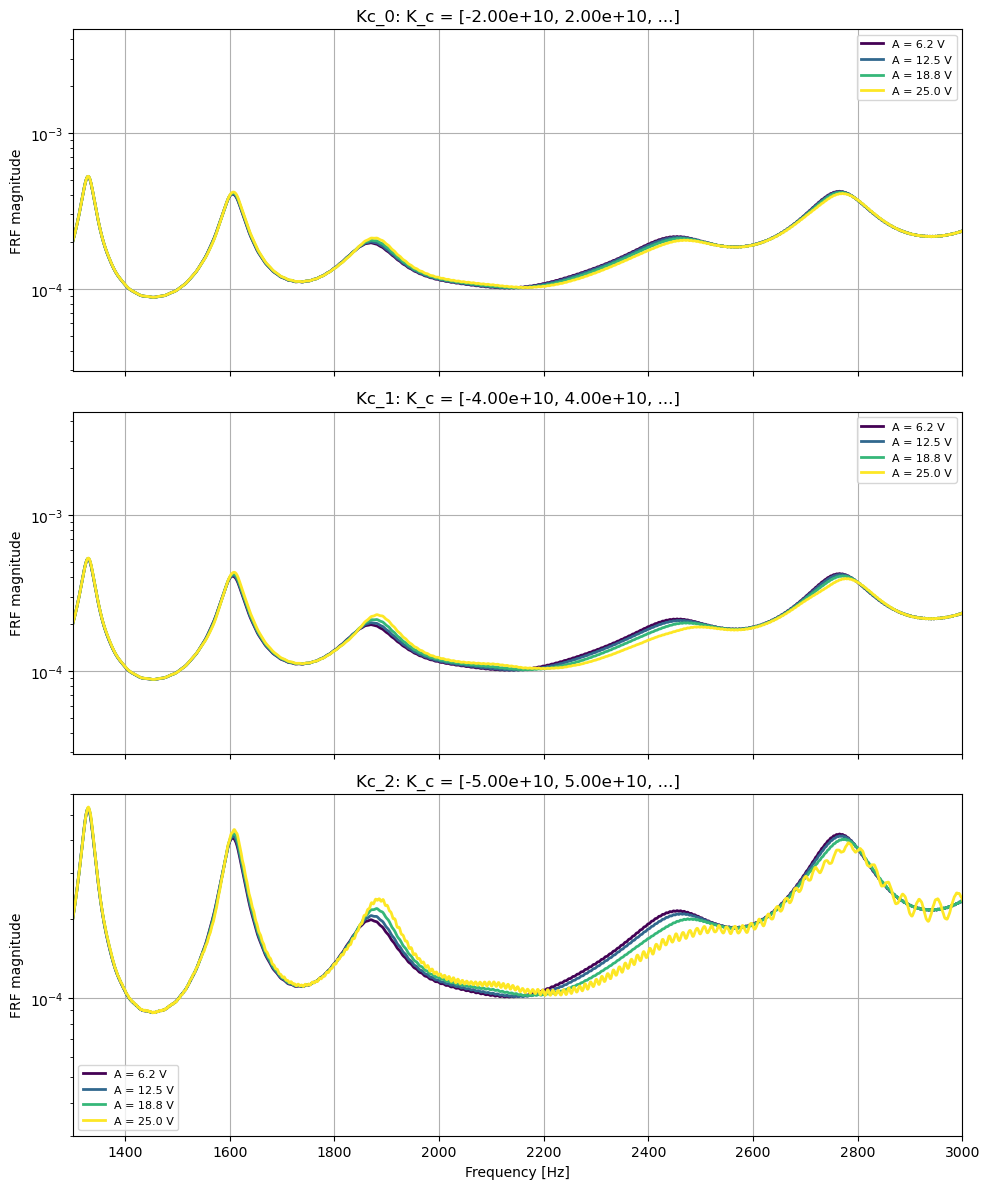

In [91]:
"""
Load FE sweep results (pickle) and plot FRFs using Kc labels
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# Load pickle file
# =========================================================
sim_dat_dir = Path.cwd() / "sim_dat"
pickle_file = sorted(sim_dat_dir.glob("FE_2D_sweep_*.pkl"))[-1]

print(f"Loading:\n  {pickle_file}")

with open(pickle_file, "rb") as f:
	data = pickle.load(f)

results_by_kc = data["results_by_kc"]
failed = data.get("failed", [])

print(f"Kc cases loaded: {len(results_by_kc)}")
print(f"Failed simulations: {len(failed)}")

# =========================================================
# Recover Kc label order (robust)
# =========================================================
# Preferred: saved explicitly at sweep time
if "Kc_labels" in data:
	kc_labels_sorted = data["Kc_labels"]
else:
	# Fallback: sort by |Kc| magnitude
	kc_labels_sorted = sorted(
		results_by_kc.keys(),
		key=lambda lbl: abs(results_by_kc[lbl]["kc_vec"][0])
	)

# =========================================================
# Plot FRFs
# =========================================================
fig, axes = plt.subplots(
	len(kc_labels_sorted), 1,
	figsize=(10, 4 * len(kc_labels_sorted)),
	sharex=True
)

if len(kc_labels_sorted) == 1:
	axes = [axes]

for ax, label in zip(axes, kc_labels_sorted):
	block = results_by_kc[label]

	cmap = plt.cm.viridis
	colors = cmap(np.linspace(0, 1, len(block["amps"])))

	for amp, res, col in zip(block["amps"], block["result"], colors):
		spec = res["spectral"]

		ax.semilogy(
			spec["freq"],
			spec["FRF"],
			color=col,
			linewidth=2,
			label=f"A = {amp:.1f} V"
		)

	kc_vec = block["kc_vec"]
	ax.set_title(
		f"{label}: K_c = [{kc_vec[0]:.2e}, {kc_vec[1]:.2e}, ...]"
	)
	ax.set_ylabel("FRF magnitude")
	ax.grid(True)
	ax.legend(fontsize=8)

axes[-1].set_xlabel("Frequency [Hz]")
axes[-1].set_xlim([1300, 3000])
axes[-1].set_ylim([3e-5, 6e-4])

plt.tight_layout()
plt.show()


Mode shape at 1799.99 Hz for Kc_1


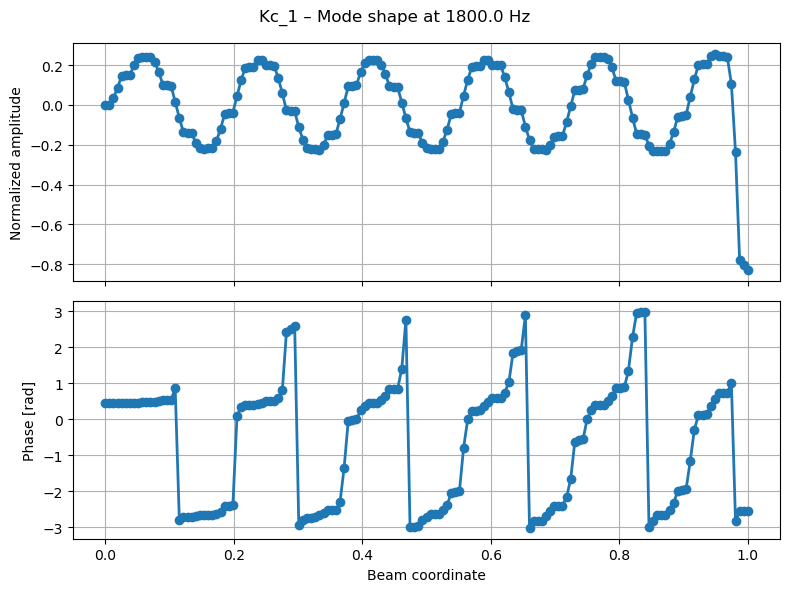

In [93]:
label = kc_labels_sorted[-2]
block = results_by_kc[label]

amp_idx = -1
res = block["result"][amp_idx]

spec = res["spectral"]
freq = spec["freq"]
Y = spec["Y"]

f_target = 1800.0
f_idx = np.argmin(np.abs(freq - f_target))

mode_shape_vel = Y[f_idx, :]
f_found = freq[f_idx]

print(f"Mode shape at {f_found:.2f} Hz for {label}")
x = np.linspace(0, 1, mode_shape_vel.size)

phi = mode_shape_vel / np.max(np.abs(mode_shape_vel))

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(x, np.real(phi), 'o-', linewidth=2)
axs[0].set_ylabel("Normalized amplitude")
axs[0].grid(True)

axs[1].plot(x, np.angle(phi), 'o-', linewidth=2)
axs[1].set_ylabel("Phase [rad]")
axs[1].set_xlabel("Beam coordinate")
axs[1].grid(True)

fig.suptitle(f"{label} – Mode shape at {f_found:.1f} Hz")
plt.tight_layout()
plt.show()



Heatmap for Kc_2, amp=25.00 V


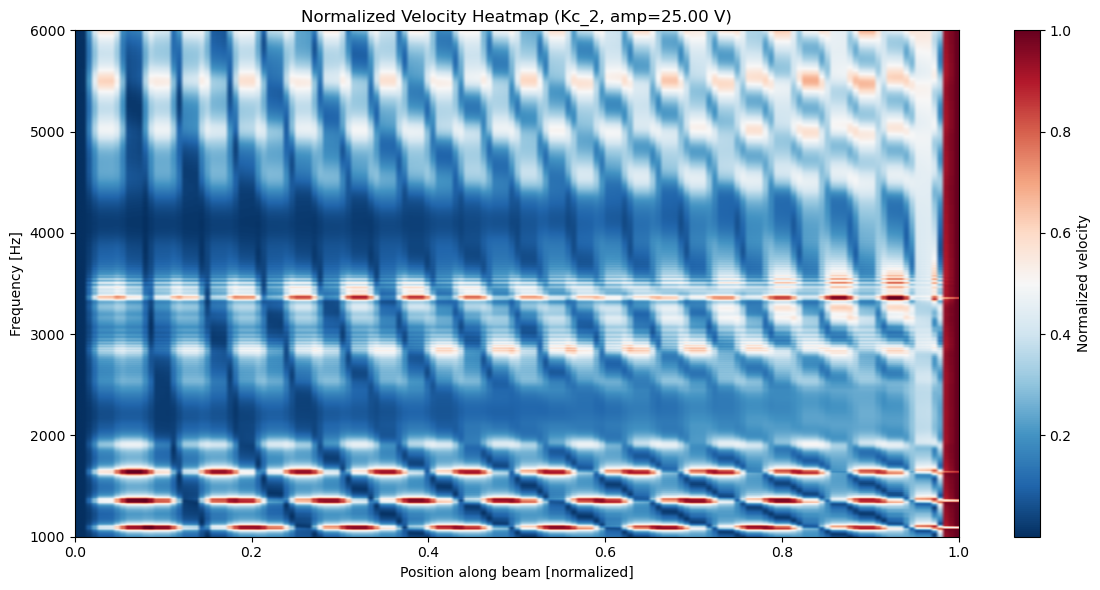

In [98]:
# Heatmap: normalized velocity for all frequencies (from spectral Y)
# Y is FFT of velocity field with shape (n_freq, n_nodes)
label = kc_labels_sorted[-1]
block = results_by_kc[label]

amp_idx = -1
res = block["result"][amp_idx]
print(f"Heatmap for {label}, amp={block['amps'][amp_idx]:.2f} V")
spec = res["spectral"]
freq = spec["freq"]
Y = spec["Y"]

v_plot_all = np.abs(Y)  # use np.abs(Y) if you want magnitude-only

# Normalize each frequency by its own maximum
v_plot_normalized = np.zeros_like(v_plot_all, dtype=float)
for i in range(v_plot_all.shape[0]):
    max_abs_i = np.max(np.abs(v_plot_all[i, :]))
    if max_abs_i > 0:
        v_plot_normalized[i, :] = v_plot_all[i, :] / max_abs_i

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    v_plot_normalized,
    aspect='auto',
    origin='lower',
    cmap='RdBu_r',
    extent=[x[0], x[-1], freq[0], freq[-1]]
)
ax.set_ylim([f0, f1])
ax.set_xlabel('Position along beam [normalized]')
ax.set_ylabel('Frequency [Hz]')
ax.set_title(f'Normalized Velocity Heatmap ({label}, amp={block["amps"][amp_idx]:.2f} V)')
plt.colorbar(im, ax=ax, label='Normalized velocity')
plt.tight_layout()
plt.show()

